<a href="https://colab.research.google.com/github/EliasHernandezBar/Proyecto-Final/blob/main/Proyecto_Integrador.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hudson Brew es una franquicia muy joven talento

---



# 1. Cemprensión del problema

# 2 Introducción

2.1 Definicion del contexto

Tras los cambios experimentados por el sector de la hostelería durante y después de la pandemia, tres cafeterías independientes ubicadas en distintos distritos de Nueva York decidieron unir sus recursos, experiencia y conocimiento del mercado para crear una nueva marca común: Hudson Brew.
La nueva franquicia nace con el objetivo de mantener la identidad y la cercanía de cada establecimiento original mientras aprovecha las ventajas de una gestión centralizada basada en datos. Gracias a esta integración, la empresa puede analizar de forma conjunta el comportamiento de sus ventas, productos y establecimientos, facilitando la toma de decisiones estratégicas orientadas al crecimiento y la mejora continua.
Actualmente, Hudson Brew opera tres cafeterías dentro de la ciudad de Nueva York y se encuentra en una fase de consolidación en la que resulta fundamental comprender el rendimiento de cada establecimiento, identificar patrones de consumo y evaluar nuevas oportunidades de expansión.


2.2 Motivación

Tras la creación de Hudson Brew y la consolidación de sus tres establecimientos bajo una misma marca, la dirección de la franquicia identificó la necesidad de comprender mejor el rendimiento de su actividad comercial y disponer de información fiable para apoyar la toma de decisiones estratégicas.
Con este propósito, la empresa contrató los servicios de un analista de datos independiente para desarrollar una solución analítica que permitiera transformar los datos operativos del negocio en información útil para la gestión. Para ello, Hudson Brew proporcionó información sobre ventas, productos, establecimientos y transacciones, con el objetivo de analizar el comportamiento de la franquicia desde una perspectiva tanto descriptiva como predictiva.
Dado el carácter reciente de la compañía y la ausencia de un histórico consolidado previo, la información disponible se limita a los primeros seis meses de actividad, lo cual condiciona el alcance del análisis y se tendrá en cuenta como base temporal de referencia.
El principal interés de la dirección consiste en evaluar el estado actual del negocio, identificar oportunidades de mejora y determinar si existen evidencias suficientes que respalden una futura expansión mediante la apertura de una nueva cafetería en la ciudad de Nueva York.
Para responder a estas necesidades, se desarrolló una solución integral que combina preparación y limpieza de los datos proporcionados en un .CSV, almacenamiento y modelado de datos en PostgreSQL, análisis exploratorio, visualización mediante dashboards interactivos y técnicas de Machine Learning orientadas a la generación de escenarios futuros.


2.3 Objetivo General

Analizar el rendimiento comercial de la franquicia Hudson Brew mediante técnicas de análisis de datos, visualización y modelado predictivo, con el objetivo de apoyar la toma de decisiones estratégicas y evaluar la viabilidad de futuras oportunidades de expansión.

2.4 Objetivos Específicos



*   Diseñar una base de datos relacional en PostgreSQL que permita almacenar y organizar la información comercial de la franquicia.
*   Implementar un modelo estrella orientado al análisis y explotación de los datos.
*   Desarrollar vistas analíticas y KPIs que faciliten la evaluación del rendimiento de ventas, productos y establecimientos.
*   Construir dashboards interactivos en Power BI para visualizar los principales indicadores del negocio.
*   Realizar un análisis exploratorio de los datos con el fin de identificar tendencias, distribuciones, comportamientos y/o relaciones relevantes.
*   Aplicar técnicas de Machine Learning para generar modelos predictivos que permitan estimar escenarios futuros de ventas.
*   Elaborar recomendaciones basadas en datos que contribuyan a la planificación estratégica de la franquicia y a la evaluación de una posible expansión.









2.5 Preguntas de negocio.

*   ¿Cómo evolucionan las ventas a lo largo del tiempo?
*   ¿Cuál es el mejor horario para promocionar ventas?
*   ¿Existen diferencias significativas entre las tres cafeterías?
*   ¿Qué categorías generan más ingresos?
*   ¿Cuáles son los productos más vendidos?
*   ¿Qué segmentos de clientes pueden identificarse?
*   ¿Existen patrones de compra según el día o el mes?
*   ¿Qué factores influyen en las ventas?
*   ¿Los datos respaldan una futura expansión de Hudson Brew?

# 3 Descripción de los Datos

3.1 Origne de la fuente de datos

El dataset utilizado para el desarrollo de este proyecto fue proporcionado por la franquicia Hudson Brew y contiene el histórico de ventas correspondiente a los seis primeros meses del año.

La información disponible se limitaba a los datos de cada transacción, incluyendo la fecha de compra, el establecimiento donde se realizó la venta, el producto adquirido y la cantidad vendida. Aunque estos datos permitían analizar la actividad comercial básica de la franquicia, resultaban insuficientes para realizar análisis más avanzados.

Con el objetivo de construir un entorno analítico más completo, se generaron variables y tablas complementarias que simulan información habitualmente disponible en una organización de este tipo como los datos de clientes, empleados responsables de la atención y métodos de pago.

La generación de estos datos se realizó mediante reglas de negocio y distribuciones controladas que garantizan la coherencia con el contexto del proyecto, permitiendo ampliar las posibilidades de análisis sin alterar la información original de ventas proporcionada por la empresa.

Gracias a este proceso fue posible diseñar un modelo de datos más robusto y desarrollar análisis relacionados con el comportamiento de los clientes, el rendimiento de los empleados y las preferencias de pago, aportando una visión más completa del funcionamiento de la franquicia.


In [1]:
import os
from google.colab import drive

# 1. Montar el drive (solo una vez por sesión)
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# 2. Aquí pegas la ruta que copiaste al hacer clic derecho en la carpeta
# Ejemplo: si tu carpeta se llama 'Proyecto_IA', la ruta sería:
ruta_proyecto = '/content/drive/Othercomputers/Mi PC/Neoland/Bootcamp Data/Proyecto Final'

In [5]:
# 3. Cambiar el directorio
os.chdir(ruta_proyecto)

In [6]:
# 4. Verificar que estás en el sitio correcto
print("Ahora estás en:", os.getcwd())
print("Archivos en esta carpeta:", os.listdir())

Ahora estás en: /content/drive/Othercomputers/Mi PC/Neoland/Bootcamp Data/Proyecto Final
Archivos en esta carpeta: ['DataSet', 'DBeaver', '.git', '.gitignore', 'Power BI', 'Informe Final', 'README.md']


3.2 Variables principales

La tabla principal del dataset contiene 149.116. Entre las variables más relevantes se encuentran el identificador de la transacción, la fecha y hora de compra, la cantidad vendida, la ubicación del establecimiento, el producto adquirido y su precio unitario.

Estas variables permiten analizar el comportamiento de las ventas desde distintas perspectivas, incluyendo la evolución temporal, el rendimiento de los establecimientos, la demanda de productos y los patrones de consumo de los clientes.


Primero doy acceso a mi Drive al Colab y luego meto la ruta donde tengo los archivos necesarios para trabajar en remoto con todo el material necesario.

In [9]:
# 1. Importar librerías

import pandas as pd

In [12]:

# Usamos la ruta completa dentro de Drive
file_path = "/content/drive/Othercomputers/Mi PC/Neoland/Bootcamp Data/Proyecto Final/DataSet/Coffee Shop Sales/Tabla Cargar SQL/Coffee Shop Sales (version 1).xlsx"

df = pd.read_excel(
    file_path,
    sheet_name="Transactions_ CoffeShop_silver"
)


In [13]:
# 3. Información general

print(f"Filas: {df.shape[0]:,}" f" Columnas: {df.shape[1]}")
print()

df.head()

Filas: 149,116 Columnas: 11



,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


3.3 Nombres de las variables

In [14]:
variables = pd.DataFrame({
    "Variable": df.columns,
    "Tipo de dato": df.dtypes.values
})

variables

,Variable,Tipo de dato
0,transaction_id,int64
1,transaction_date,datetime64[ns]
2,transaction_time,object
3,transaction_qty,int64
4,store_id,int64
5,store_location,object
6,product_id,int64
7,unit_price,float64
8,product_category,object
9,product_type,object


In [15]:
pd.DataFrame({
    "Variable": df.columns,
    "Valores nulos": df.isnull().sum().values
})

,Variable,Valores nulos
0,transaction_id,0
1,transaction_date,0
2,transaction_time,0
3,transaction_qty,0
4,store_id,0
5,store_location,0
6,product_id,0
7,unit_price,0
8,product_category,0
9,product_type,0


In [16]:
df.describe()

,transaction_id,transaction_date,transaction_qty,store_id,product_id,unit_price
count,149116.000000,149116,149116.000000,149116.000000,149116.000000,149116.000000
mean,74737.371872,2023-04-15 11:50:32.173609984,1.438276,5.342063,47.918607,3.382219
min,1.000000,2023-01-01 00:00:00,1.000000,3.000000,1.000000,0.800000
25%,37335.750000,2023-03-06 00:00:00,1.000000,3.000000,33.000000,2.500000
50%,74727.500000,2023-04-24 00:00:00,1.000000,5.000000,47.000000,3.000000
75%,112094.250000,2023-05-30 00:00:00,2.000000,8.000000,60.000000,3.750000
max,149456.000000,2023-06-30 00:00:00,8.000000,8.000000,87.000000,45.000000
std,43153.600016,NaN,0.542509,2.074241,17.930020,2.658723


In [17]:
print("Número de registros:", len(df))
print("Número de variables:", len(df.columns))
print()
print('Nombres de las variables:')
for col in df.columns:
    print(col)


Número de registros: 149116
Número de variables: 11

Nombres de las variables:
transaction_id
transaction_date
transaction_time
transaction_qty
store_id
store_location
product_id
unit_price
product_category
product_type
product_detail


3.4 Limitaciones

Dado el carácter reciente de la compañía, la base de datos disponible se limita a los primeros seis meses de actividad. Esta circunstancia supone una restricción relevante en términos de análisis temporal, ya que no se dispone de un histórico suficientemente amplio que permita evaluar patrones estacionales completos o comportamientos a largo plazo con mayor robustez.

# 4 Preparación y Limpieza

4.1 Procesos realizados

A partir del dataset original proporcionado por Hudson Brew se realizó un proceso de preparación y enriquecimiento de los datos con el objetivo de construir una base de datos más completa para el análisis.

Se revisó la calidad de los datos, formatos, tipos y posibles inconsistencias.Despues se generó información complementaria no disponible en el dataset original, incluyendo datos de clientes, empleados y métodos de pago. Estos datos fueron creados mediante reglas de negocio y distribuciones controladas para simular un entorno empresarial realista y ampliar las posibilidades de análisis.

La información fue organizada siguiendo criterios de normalización y separada en diferentes tablas para facilitar su almacenamiento y explotación.

4.2 Herramientas utilizadas

Durante esta fase se emplearon las siguientes herramientas:


*   Microsoft Excel para la generación y transformación inicial de los datos complementarios.
*   PostgreSQL como sistema gestor de bases de datos.
*   DBeaver como entorno de administración y desarrollo SQL.
*   SQL para la creación de tablas, relaciones y procesos de carga de datos.








4.3 Transformaciones aplicadas

Con el fin de optimizar almacenamiento y facilitar el análisis, los datos fueron transformados y organizados en distintas tablas independientes.

Se crearon tablas específicas para clientes, empleados, métodos de pago, productos y establecimientos, permitiendo reducir redundancias y mejorar la integridad de la información mediante el uso de claves primarias y foráneas.

Posteriormente, estas tablas fueron cargadas en PostgreSQL y utilizadas para construir  el modelo estrella empleado en la capa analítica.

La métrica total_amount no formaba parte del dataset original ni fue almacenada en las tablas operacionales. Fue calculado posteriormente en la capa analítica mediante la combinación de la cantidad vendida (transaction_qty) y el precio unitario del producto (unit_price), evitando así la duplicidad de información almacenada.

### Modelo de Datos

Las siguientes figuras muestran la estructura de las bases de datos desarrolladas durante el proyecto.

La primera corresponde a la capa operacional (`coffee_shop`).

La segunda representa la capa analítica (`analitica`), diseñada siguiendo un modelo estrella.

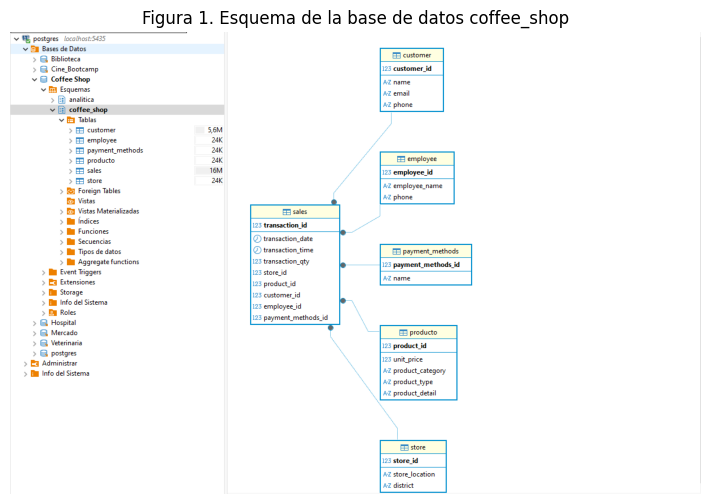

In [19]:
from PIL import Image
import matplotlib.pyplot as plt

img1 = Image.open("/content/drive/Othercomputers/Mi PC/Neoland/Bootcamp Data/Proyecto Final/Informe Final/Capturas SQL/coffee_shop.PNG")

plt.figure(figsize=(12,6))
plt.imshow(img1)
plt.title("Figura 1. Esquema de la base de datos coffee_shop")
plt.axis("off")
plt.show()

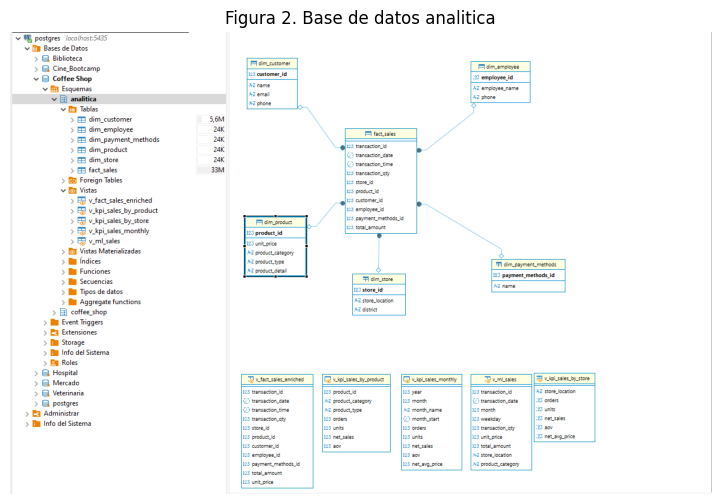

In [20]:
from PIL import Image

img2 = Image.open("/content/drive/Othercomputers/Mi PC/Neoland/Bootcamp Data/Proyecto Final/Informe Final/Capturas SQL/analitica.PNG")

plt.figure(figsize=(12,6))
plt.imshow(img2)
plt.title("Figura 2. Base de datos analitica")
plt.axis("off")
plt.show()

Dimensiones (CTAS) - dim_product



```
# CREATE TABLE analitica.dim_product AS
SELECT DISTINCT
    p."product_id"          AS product_id,
    p."unit_price"  AS unit_price,
    p."product_category"        AS product_category,
    p."product_type"			AS product_type,
    p."product_detail"			AS product_detail
FROM coffee_shop.producto p;

select * from analitica.dim_product;

ALTER TABLE analitica.dim_product
  ADD CONSTRAINT pk_dim_product PRIMARY KEY (product_id);
```




3) Hechos (CTAS) - fact_sales

   Crear una columna 'total_amount' con el total de cada venta
   
   Introducir el total a cada transacción/venta



```
# CREATE TABLE analitica.fact_sales AS
SELECT
s."transaction_id"          AS transaction_id,
s."transaction_date"		AS transaction_date,
s."transaction_time"		AS transaction_time,
s."transaction_qty"			AS transaction_qty,
s."store_id"				as store_id,
s."product_id"				as product_id,
s."customer_id"				as customer_id,
s."employee_id"				as employee_id,
s."payment_methods_id"		as payment_methods_id
from coffee_shop.sales s;

select * from analitica.fact_sales limit 100;

-- Una vez cargados los datos, vamos a generar una nueva columna total
ALTER TABLE analitica.fact_sales
ADD COLUMN total_amount DECIMAL(10,2);
-- Actualizamos la tabla total multiplicando las unidades vendidas por el precio por unidad
UPDATE analitica.fact_sales s
SET total_amount = s.transaction_qty * p.unit_price
FROM producto p
WHERE p.product_id = s.product_id;

-- Índices útiles para joins analíticos
CREATE INDEX ix_fact_sales_customer   ON analitica.fact_sales (customer_id);
CREATE INDEX ix_fact_sales_producto    ON analitica.fact_sales (product_id);
CREATE INDEX ix_fact_sales_employee   ON analitica.fact_sales (employee_id);
CREATE INDEX ix_fact_sales_store     ON analitica.fact_sales (store_id);
CREATE INDEX ix_fact_sales_payment_methods   ON analitica.fact_sales (payment_methods_id);
```



Vista detalle de la tabla sales enriquecida



```
# CREATE OR REPLACE VIEW analitica.v_fact_sales_enriched AS
SELECT
    fs.*,
    p.unit_price
FROM analitica.fact_sales fs
JOIN analitica.dim_product p
    ON fs.product_id = p.product_id
ORDER BY fs.transaction_id;
```



 Vista KPI mensual (agregada por mes)



```
# CREATE OR REPLACE VIEW analitica.v_kpi_sales_monthly AS
SELECT
  EXTRACT(YEAR FROM transaction_date) AS year,
  EXTRACT(MONTH FROM transaction_date) AS month,
  TO_CHAR(transaction_date, 'FMMonth') AS month_name,
  DATE_TRUNC('month', transaction_date) AS month_start,

  COUNT(DISTINCT transaction_id) AS orders,
  SUM(transaction_qty) AS units,
  SUM(total_amount) AS net_sales,

  SUM(total_amount) / NULLIF(COUNT(DISTINCT transaction_id), 0) AS aov,
  SUM(total_amount) / NULLIF(SUM(transaction_qty), 0) AS net_avg_price

FROM analitica.v_fact_sales_enriched
GROUP BY
  EXTRACT(YEAR FROM transaction_date),
  EXTRACT(MONTH FROM transaction_date),
  TO_CHAR(transaction_date, 'FMMonth'),
  DATE_TRUNC('month', transaction_date);
```



# 5 Base de Datos SQL

5.1 Modelo utilizado

La solución desarrollada se basa en una arquitectura de datos compuesta por una capa operacional y una capa analítica.

Se utilizó el dataset proporcionado por Hudson Brew en formato Excel. Este conjunto de datos se limpio para poder usarlo como capa Silver dentro del flujo de trabajo, sirviendo como fuente para el proceso ETL (Extract, Transform, Load).

Los datos fueron importados a PostgreSQL y distribuidos en distintas tablas normalizadas dentro de la base de datos **coffee_shop**. Esta capa se diseñó para almacenar la información de forma estructurada, garantizando la integridad de los datos mediante claves primarias y foráneas.

Una vez consolidada la información operacional, se desarrolló una segunda capa denominada **analitica**, basada en un modelo estrella. Este modelo está compuesto por una tabla de hechos (`fact_sales`) y varias tablas dimensionales (`dim_product`, `dim_store`, `dim_customer`, `dim_employee` y `dim_payment_method`).

Sobre esta capa se construyeron diversas vistas orientadas al análisis de ventas, generación de KPIs y preparación de datasets para Machine Learning, que posteriormente fueron utilizados en Power BI y Python para la elaboración de visualizaciones y modelos predictivos.

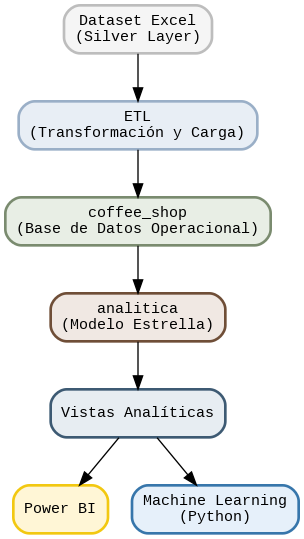

In [21]:
from graphviz import Digraph
from IPython.display import Image, display

# Crear diagrama
dot = Digraph(comment='Arquitectura Hudson Brew')

# Dirección vertical
dot.attr(rankdir='TB')

# Estilo general de nodos
dot.attr(
    'node',
    shape='box',
    style='rounded,filled',
    fontname='Montserrat',
    fontsize='11'
)

# Nodos
dot.node(
    'A',
    'Dataset Excel\n(Silver Layer)',
    fillcolor='#F5F5F5',
    color='#BDBDBD',
    penwidth='2'
)

dot.node(
    'B',
    'ETL\n(Transformación y Carga)',
    fillcolor='#E8EEF5',
    color='#9AAFC7',
    penwidth='2'
)

dot.node(
    'C',
    'coffee_shop\n(Base de Datos Operacional)',
    fillcolor='#E8EEE5',
    color='#7A8B6F',
    penwidth='2'
)

dot.node(
    'D',
    'analitica\n(Modelo Estrella)',
    fillcolor='#F0E8E3',
    color='#6F4E37',
    penwidth='2'
)

dot.node(
    'E',
    'Vistas Analíticas',
    fillcolor='#E7EDF2',
    color='#3D5A73',
    penwidth='2'
)

dot.node(
    'F',
    'Power BI',
    fillcolor='#FFF6D6',
    color='#F2C811',
    penwidth='2'
)

dot.node(
    'G',
    'Machine Learning\n(Python)',
    fillcolor='#E6F0FA',
    color='#3776AB',
    penwidth='2'
)

# Relaciones
dot.edge('A', 'B')
dot.edge('B', 'C')
dot.edge('C', 'D')
dot.edge('D', 'E')
dot.edge('E', 'F')
dot.edge('E', 'G')

# Guardar y mostrar
dot.render(
    'arquitectura_hudson_brew',
    format='png',
    cleanup=True
)

display(Image(filename='arquitectura_hudson_brew.png'))

5.2 Tablas creadas

Base de datos operacional: coffee_shop

La base de datos operacional fue diseñada siguiendo principios de normalización con el objetivo de almacenar la información de forma estructurada y minimizar redundancias.

Las principales tablas creadas fueron:

| Tabla           | Descripción                              |
| --------------- | ---------------------------------------- |
| customers       | Información de los clientes              |
| employees       | Información de los empleados             |
| payment_methods | Métodos de pago utilizados               |
| products        | Catálogo de productos                    |
| stores          | Información de los establecimientos      |
| transactions    | Registro de las transacciones realizadas |


Base de datos analítica: analitica

A partir de la capa operacional se desarrolló un modelo estrella orientado al análisis de negocio.

| Tabla              | Tipo            |
| ------------------ | --------------- |
| fact_sales         | Tabla de hechos |
| dim_product        | Dimensión       |
| dim_store          | Dimensión       |
| dim_customer       | Dimensión       |
| dim_employee       | Dimensión       |
| dim_payment_method | Dimensión       |


Vistas analíticas creadas

| Vista                  | Objetivo                        |
| ---------------------- | ------------------------------- |
| v_fact_sales_enriched  | Enriquecimiento de ventas       |
| v_kpi_sales_monthly    | KPIs mensuales                  |
| v_kpi_sales_by_product | Rendimiento de productos        |
| v_kpi_sales_by_store   | Rendimiento de establecimientos |
| v_ml_sales_dataset     | Dataset para Machine Learning   |


In [22]:
!pip install sqlalchemy psycopg2-binary seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 42.3 MB/s eta 0:00:00


In [23]:
#Importaciones básicas

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
import getpass

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')


In [26]:
#Parámetros de conexión (ngrok authtoken)

host = '4.tcp.eu.ngrok.io'
port = '25769'
database = 'Coffee Shop'
user = 'postgres'
password = getpass.getpass('Contraseña de PostgreSQL: ')

engine = create_engine(
    f'postgresql+psycopg2://{user}:{password}@{host}:{port}/{database}'
)

Contraseña de PostgreSQL: ··········


In [27]:
#Prueba rápida de conexión

with engine.connect() as conn:
    resultado = pd.read_sql(text('SELECT 1 AS prueba_conexion'), conn)

resultado

,prueba_conexion
0,1


In [28]:
#Base de datos operacional: coffee_shop

consulta_vistas = """
SELECT table_schema, table_name
FROM information_schema.tables
WHERE table_schema = 'coffee_shop'
ORDER BY table_name;
"""

pd.read_sql(consulta_vistas, engine)

,table_schema,table_name
0,coffee_shop,customer
1,coffee_shop,employee
2,coffee_shop,payment_methods
3,coffee_shop,producto
4,coffee_shop,sales
5,coffee_shop,store


In [29]:
#Ver las vistas disponibles

consulta_vistas = """
SELECT table_schema, table_name
FROM information_schema.tables
WHERE table_schema = 'analitica' AND table_type = 'BASE TABLE'
ORDER BY table_name;
"""

pd.read_sql(consulta_vistas, engine)

,table_schema,table_name
0,analitica,dim_customer
1,analitica,dim_employee
2,analitica,dim_payment_methods
3,analitica,dim_product
4,analitica,dim_store
5,analitica,fact_sales


In [36]:
#Ver las vistas disponibles

consulta_vistas = """
SELECT table_schema, table_name
FROM information_schema.views
WHERE table_schema = 'analitica'
ORDER BY table_name;
"""

pd.read_sql(consulta_vistas, engine)

,table_schema,table_name
0,analitica,v_fact_sales_enriched
1,analitica,v_kpi_sales_by_product
2,analitica,v_kpi_sales_by_store
3,analitica,v_kpi_sales_monthly
4,analitica,v_ml_sales


5.3 Consultas principales

Consulta 1. Creación de la tabla de hechos



```
# CREATE TABLE analitica.fact_sales AS
SELECT
    transaction_id,
    transaction_date,
    transaction_time,
    transaction_qty,
    store_id,
    product_id,
    customer_id,
    employee_id,
    payment_methods_id
FROM coffee_shop.transactions;
```



Objetivo: Centralizar todas las transacciones de venta dentro del modelo estrella.

Consulta 2. Vista enriquecida de ventas



```
# CREATE OR REPLACE VIEW analitica.v_fact_sales_enriched AS
SELECT
    fs.*,
    p.unit_price,
    fs.transaction_qty * p.unit_price AS total_amount
FROM analitica.fact_sales fs
JOIN analitica.dim_product p
    ON fs.product_id = p.product_id;
```



Objetivo: Incorporar el precio unitario y calcular el importe total de cada venta.

Consulta 3. KPI mensual



```
# SELECT
    DATE_TRUNC('month', transaction_date) AS month_start,
    SUM(total_amount) AS net_sales
FROM analitica.v_fact_sales_enriched
GROUP BY month_start
ORDER BY month_start;
```



Objetivo: Analizar la evolución mensual de las ventas.

Consulta 4. KPI por tienda



```
# SELECT
    ds.store_location,
    SUM(fs.total_amount) AS net_sales
FROM analitica.v_fact_sales_enriched fs
JOIN analitica.dim_store ds
    ON fs.store_id = ds.store_id
GROUP BY ds.store_location;
```



Objetivo: Comparar el rendimiento comercial de los establecimientos.

Consulta 5. Dataset para Machine Learning



```
# CREATE OR REPLACE VIEW analitica.v_ml_sales_dataset AS
SELECT
    fs.transaction_id,
    EXTRACT(MONTH FROM fs.transaction_date) AS month,
    EXTRACT(DOW FROM fs.transaction_date) AS weekday,
    fs.transaction_qty,
    fs.unit_price,
    fs.total_amount,
    ds.store_location,
    dp.product_category
FROM analitica.v_fact_sales_enriched fs
JOIN analitica.dim_store ds
    ON fs.store_id = ds.store_id
JOIN analitica.dim_product dp
    ON fs.product_id = dp.product_id;
```



Objetivo: Preparar un conjunto de datos optimizado para análisis predictivo y técnicas de Machine Learning.

# 6 Análisis Exploratorio

6.1 Objetivo del análisis

El objetivo del análisis exploratorio fue comprender el comportamiento de las ventas de Hudson Brew, identificar patrones de consumo y detectar oportunidades de negocio que permitieran apoyar la toma de decisiones estratégicas de la franquicia.

6.2 Estadísticas descriptivas

In [37]:
#Información general del dataset

info_dataset = pd.DataFrame({
    "Indicador": [
        "Número de registros",
        "Número de variables",
        "Fecha mínima",
        "Fecha máxima"
    ],
    "Valor": [
        len(df),
        len(df.columns),
        df["transaction_date"].min(),
        df["transaction_date"].max()
    ]
})

info_dataset

,Indicador,Valor
0,Número de registros,149116
1,Número de variables,12
2,Fecha mínima,2023-01-01 00:00:00
3,Fecha máxima,2023-06-30 00:00:00


In [43]:
#Métricas generales



kpis = pd.DataFrame({
    "Métrica": [
        "Nº de transacciones",
        "Ventas totales",
        "Ticket medio (AOV)",
        "Productos vendidos"
    ],
    "Valor": [
        df["transaction_id"].nunique(),
        round(df["total_amount"].sum(), 2),
        round(df["total_amount"].mean(), 2),
        df["transaction_qty"].sum()
    ]
})
print("KPIs generales")
print()
kpis

KPIs generales



,Métrica,Valor
0,Nº de transacciones,149116.00
1,Ventas totales,698812.33
2,Ticket medio (AOV),4.69
3,Productos vendidos,214470.00


In [44]:
#Estadísticas descriptivas

estadisticas = (
    df[
        ["transaction_qty",
         "unit_price",
         "total_amount"]
    ]
    .describe()
    .round(2)
)
print("Estadísticas numéricas")
print()
estadisticas

Estadísticas numéricas



,transaction_qty,unit_price,total_amount
count,149116.00,149116.00,149116.00
mean,1.44,3.38,4.69
std,0.54,2.66,4.23
min,1.00,0.80,0.80
25%,1.00,2.50,3.00
50%,1.00,3.00,3.75
75%,2.00,3.75,6.00
max,8.00,45.00,360.00


In [45]:
resumen_estadisticas = (
    df[
        ["transaction_qty",
         "unit_price",
         "total_amount"]
    ]
    .agg([
        "mean",
        "median",
        "min",
        "max"
    ])
    .round(2)
)

resumen_estadisticas

,transaction_qty,unit_price,total_amount
mean,1.44,3.38,4.69
median,1.00,3.00,3.75
min,1.00,0.80,0.80
max,8.00,45.00,360.00


6.3 Evolución temporal de las ventas

¿Cómo evolucionan las ventas a lo largo del tiempo?

El objetivo de este análisis es identificar tendencias en las ventas de la franquicia durante el periodo estudiado, detectando posibles incrementos o descensos de la actividad comercial.

In [46]:
query = """
SELECT *
FROM analitica.v_kpi_sales_monthly
ORDER BY month_start
"""

df_monthly = pd.read_sql(query, engine)

df_monthly.head()

,year,month,month_name,month_start,orders,units,net_sales,aov,net_avg_price
0,2023.0,1.0,January,2023-01-01 00:00:00+01:00,17314,24870,81934.04,4.732242,3.294493
1,2023.0,2.0,February,2023-02-01 00:00:00+01:00,16359,23550,76356.72,4.667566,3.242324
2,2023.0,3.0,March,2023-03-01 00:00:00+01:00,21229,30406,99104.40,4.668350,3.259370
3,2023.0,4.0,April,2023-04-01 00:00:00+02:00,25335,36469,119296.23,4.708752,3.271168
4,2023.0,5.0,May,2023-05-01 00:00:00+02:00,33527,48233,157107.74,4.686007,3.257267


**Visualización**

Ventas mensuales

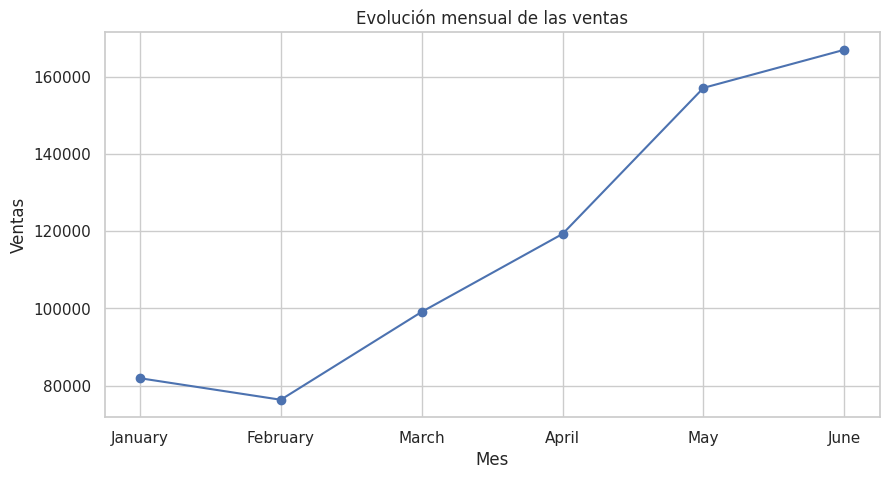

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    df_monthly["month_name"],
    df_monthly["net_sales"],
    marker="o"
)

plt.title("Evolución mensual de las ventas")
plt.xlabel("Mes")
plt.ylabel("Ventas")
plt.grid(True)

plt.show()

Mes con mayores ventas:

In [53]:
best_month = df_monthly.loc[
    df_monthly["net_sales"].idxmax()
]

best_month

,5
year,2023.0
month,6.0
month_name,June
month_start,2023-06-01 00:00:00+02:00
orders,35352
units,50942
net_sales,166980.61
aov,4.723371
net_avg_price,3.277857


Mes con menores ventas:

In [54]:
worst_month = df_monthly.loc[
    df_monthly["net_sales"].idxmin()
]

worst_month

,1
year,2023.0
month,2.0
month_name,February
month_start,2023-02-01 00:00:00+01:00
orders,16359
units,23550
net_sales,76356.72
aov,4.667566
net_avg_price,3.242324


**Crecimiento mensual**

In [55]:
df_monthly["growth_pct"] = (
    df_monthly["net_sales"]
    .pct_change() * 100
)

df_monthly.round(2)

,year,month,month_name,month_start,orders,units,net_sales,aov,net_avg_price,growth_pct
0,2023.0,1.0,January,2023-01-01 00:00:00+01:00,17314,24870,81934.04,4.73,3.29,NaN
1,2023.0,2.0,February,2023-02-01 00:00:00+01:00,16359,23550,76356.72,4.67,3.24,-6.81
2,2023.0,3.0,March,2023-03-01 00:00:00+01:00,21229,30406,99104.40,4.67,3.26,29.79
3,2023.0,4.0,April,2023-04-01 00:00:00+02:00,25335,36469,119296.23,4.71,3.27,20.37
4,2023.0,5.0,May,2023-05-01 00:00:00+02:00,33527,48233,157107.74,4.69,3.26,31.70
5,2023.0,6.0,June,2023-06-01 00:00:00+02:00,35352,50942,166980.61,4.72,3.28,6.28


Aquí podemos observar el crecimiento respecto al mes anterior. Por ello en el mes de enero aparece NaN, ya que no tiene datos con los que compararse.

El **análisis de la evolución** temporal muestra que las ventas mantienen una tendencia claramente creciente durante el periodo analizado. Las ventas pasaron de 81.934,04 dólares en enero a 157.107,74 dólares en mayo, lo que supone un incremento acumulado del 103,80%.

El mes con mayor volumen de ventas fue mayo, mientras que febrero registró la menor facturación del periodo. A partir de marzo se observa una aceleración progresiva de las ventas, consolidándose durante abril, mayo y junio.

La pendiente positiva de la línea de tendencia confirma la existencia de un crecimiento durante toda la actividad comercial. Este comportamiento sugiere una demanda creciente de los productos ofrecidos por Hudson Brew.




In [56]:
import numpy as np

x = np.arange(len(df_monthly))
y = df_monthly["net_sales"]

pendiente, intercepto = np.polyfit(x, y, 1)

print("Pendiente:", pendiente)

Pendiente: 19647.935428571418


In [57]:
primer_mes = df_monthly["net_sales"].iloc[0]
ultimo_mes = df_monthly["net_sales"].iloc[-1]

variacion = ((ultimo_mes - primer_mes) / primer_mes) * 100

print(f"Variación total: {variacion:.2f}%")

Variación total: 103.80%


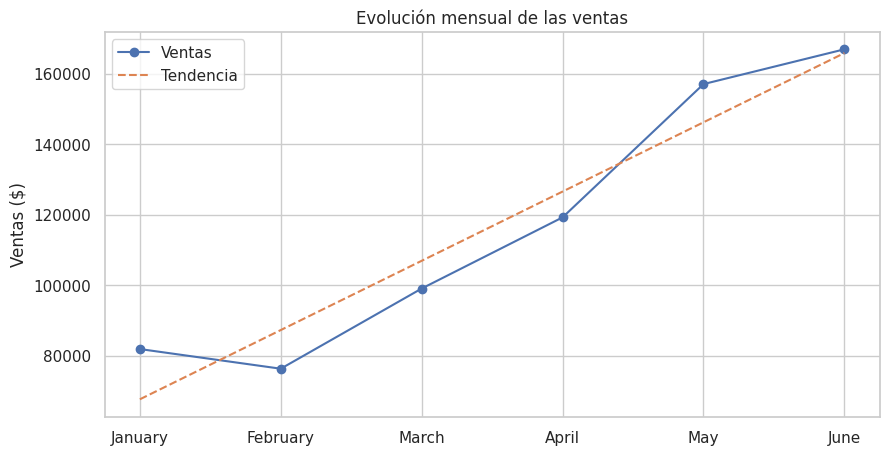

In [58]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(df_monthly))
y = df_monthly["net_sales"]

pendiente, intercepto = np.polyfit(x, y, 1)
tendencia = pendiente * x + intercepto

plt.figure(figsize=(10,5))

plt.plot(
    df_monthly["month_name"],
    y,
    marker="o",
    label="Ventas"
)

plt.plot(
    df_monthly["month_name"],
    tendencia,
    linestyle="--",
    label="Tendencia"
)

plt.title("Evolución mensual de las ventas")
plt.ylabel("Ventas ($)")
plt.legend()

plt.show()

La tendencia positiva observada durante el primer semestre sugiere que **Hudson Brew** dispone una tendencia comercial en crecimiento, aspecto que deberá considerarse junto con el análisis por tiendas, productos y patrones de consumo para evaluar la viabilidad de una futura apertura.

6.4 Análisis por horario

El objetivo de este análisis es identificar los periodos de mayor y menor actividad comercial a lo largo del día para optimizar pisibles campañas promocionales y estrategias de venta.

In [66]:
query = """
SELECT
    EXTRACT(HOUR FROM transaction_time) AS hour,
    COUNT(*) AS transactions,
    SUM(total_amount) AS net_sales
FROM analitica.v_fact_sales_enriched
GROUP BY hour
ORDER BY hour;
"""

engine.dispose()

df_hourly = pd.read_sql(query, engine)

df_hourly['hour'] = df_hourly['hour'].astype(int)

df_hourly

,hour,transactions,net_sales
0,6,4594,21984.77
1,7,13428,63704.73
2,8,17654,83080.63
3,9,17764,85388.32
4,10,18545,88960.69
5,11,9766,46444.38
6,12,8708,40340.75
7,13,8714,40510.07
8,14,8933,41487.38
9,15,8979,41740.70


Gráfico de las ventas por hora

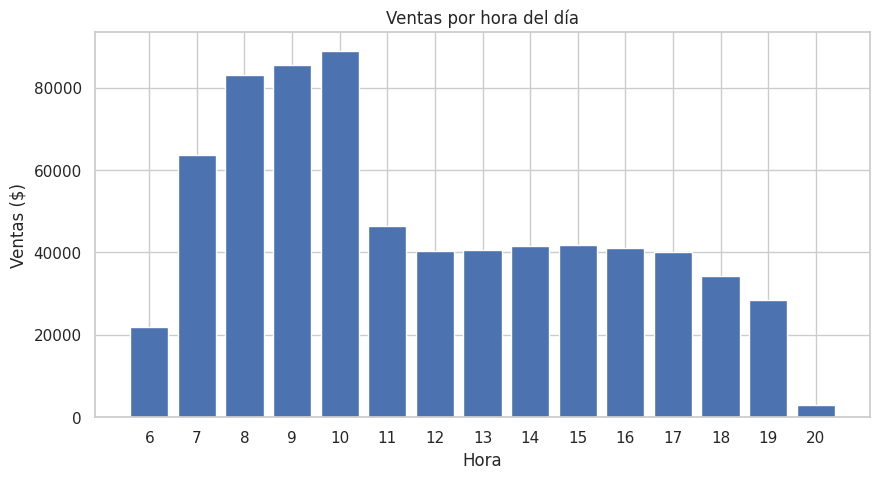

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    df_hourly["hour"],
    df_hourly["net_sales"]
)

plt.title("Ventas por hora del día")
plt.xlabel("Hora")
plt.ylabel("Ventas ($)")

plt.xticks(df_hourly["hour"])

plt.show()

Hora con mayores ventas

In [68]:
best_hour = df_hourly.loc[
    df_hourly["net_sales"].idxmax()
]

best_hour

,4
hour,10.00
transactions,18545.00
net_sales,88960.69


Hora con menores ventas

In [69]:
worst_hour = df_hourly.loc[
    df_hourly["net_sales"].idxmin()
]

worst_hour

,14
hour,20.00
transactions,603.00
net_sales,2970.62


Estas son las tres mejores horas en ventas

In [70]:
df_hourly.nlargest(3, "net_sales")

,hour,transactions,net_sales
4,10,18545,88960.69
3,9,17764,85388.32
2,8,17654,83080.63


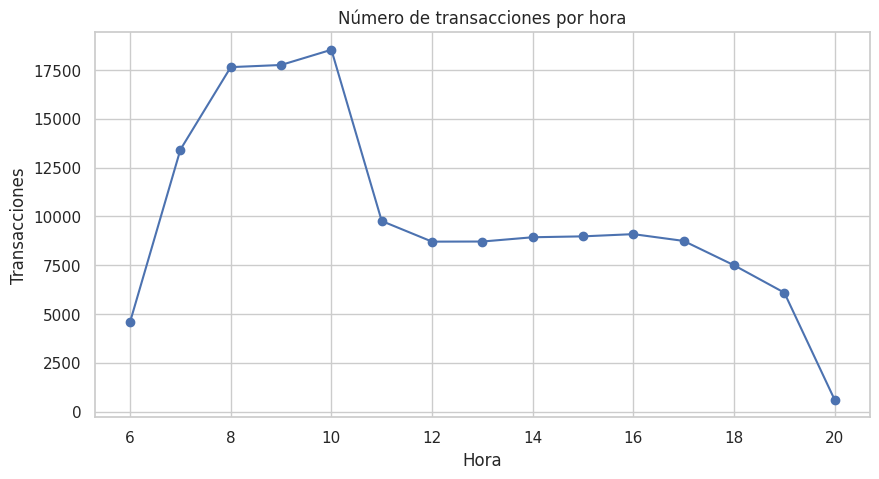

In [78]:
plt.figure(figsize=(10,5))

plt.plot(
    df_hourly["hour"],
    df_hourly["transactions"],
    marker="o"
)

plt.title("Número de transacciones por hora")
plt.xlabel("Hora")
plt.ylabel("Transacciones")

plt.grid(True)

plt.show()

El **análisis horario** muestra que la **actividad comercial** de Hudson Brew no se distribuye de forma homogénea a lo largo del día.

Las mayores ventas se concentran durante las primeras horas de la mañana, coincidiendo con los momentos de mayor afluencia de clientes. Por el contrario, las franjas comprendidas entre 18 y 20 registran los niveles más bajos de actividad.

Estos resultados reflejan hábitos de consumo asociados a la compra de café y productos de acompañamiento durante determinados momentos del día, especialmente en horarios de desayuno y media mañana.

Desde una perspectiva de negocio, las horas de menor actividad representan una oportunidad para implementar promociones que permitan incrementar el flujo de clientes y mejorar el aprovechamiento de la capacidad operativa de los establecimientos.

también puntualizar que hay una franja de horas comprendida entre las 11 y las 17 donde hay una afluencia, que aunque es más baja que la mañana, es estable en el tiempo. Puede ser otra oportunidad de aumentar la afluencia de ese tipo o perfil de consumo.



6.5 Análisis por tienda

El objetivo de este análisis es comparar las tres cafeterías que forman Hudson Brew para identificar fortalezas, diferencias operativas y posibles oportunidades de crecimiento.

**Datos a analizar**

1. Ventas totales por tienda

Mide la capacidad de generar ingresos.

2. Ticket medio por tienda

Mide cuánto gasta cada cliente por transacción.

3. Participación en ingresos

Mide qué porcentaje del negocio aporta cada establecimiento.

In [92]:
query = """
SELECT *
FROM analitica.v_kpi_sales_by_store
"""

df_store = pd.read_sql(query, engine)

df_store

,store_location,orders,units,net_sales,aov,net_avg_price
0,Hell's Kitchen,50735,71737,237509.27,4.68,3.31
1,Astoria,50599,70991,232356.91,4.59,3.27
2,Lower Manhattan,47782,71742,230913.56,4.83,3.22


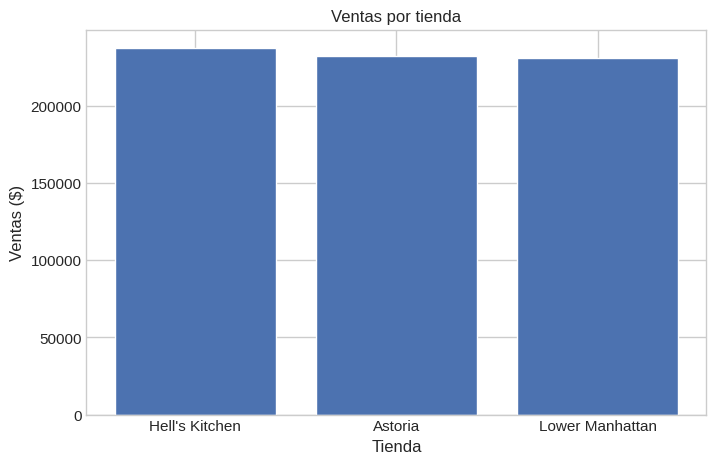

In [93]:
#Gráfico 1 - Ventas por tienda

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    df_store["store_location"],
    df_store["net_sales"]
)

plt.title("Ventas por tienda")
plt.xlabel("Tienda")
plt.ylabel("Ventas ($)")

plt.show()

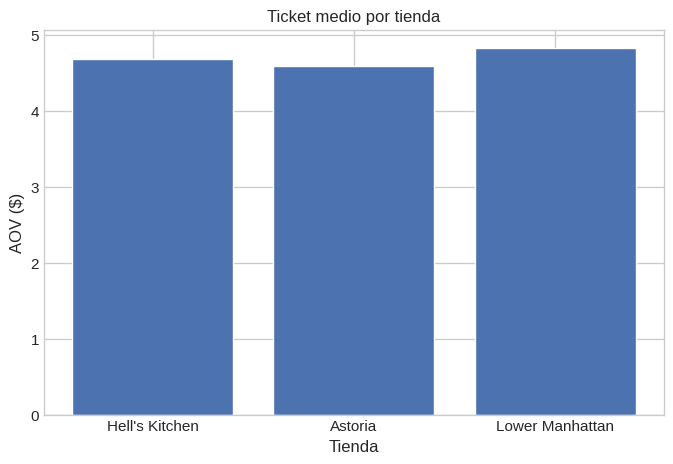

In [94]:
#Gráfico 2 - Ticket medio (AOV)

plt.figure(figsize=(8,5))

plt.bar(
    df_store["store_location"],
    df_store["aov"]
)

plt.title("Ticket medio por tienda")
plt.xlabel("Tienda")
plt.ylabel("AOV ($)")

plt.show()

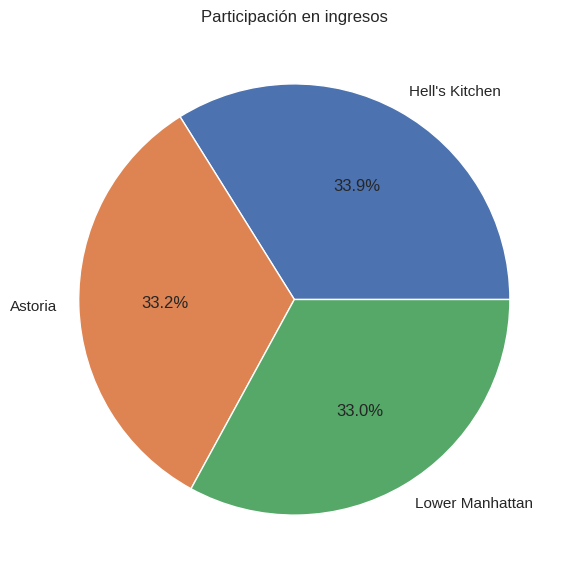

In [95]:
#Gráfico 3 - Participación en ingresos

plt.figure(figsize=(7,7))

plt.pie(
    df_store["net_sales"],
    labels=df_store["store_location"],
    autopct="%1.1f%%"
)

plt.title("Participación en ingresos")

plt.show()

In [96]:
mejor_tienda = df_store.loc[
    df_store["net_sales"].idxmax()
]

mejor_tienda

,0
store_location,Hell's Kitchen
orders,50735
units,71737
net_sales,237509.27
aov,4.68
net_avg_price,3.31


In [97]:
mayor_ticket = df_store.loc[
    df_store["aov"].idxmax()
]

mayor_ticket

,2
store_location,Lower Manhattan
orders,47782
units,71742
net_sales,230913.56
aov,4.83
net_avg_price,3.22


Análisis de los resultados obtenidos

In [99]:
df_store

,store_location,orders,units,net_sales,aov,net_avg_price
0,Hell's Kitchen,50735,71737,237509.27,4.68,3.31
1,Astoria,50599,70991,232356.91,4.59,3.27
2,Lower Manhattan,47782,71742,230913.56,4.83,3.22


El análisis muestra un **rendimiento equilibrado** entre las tres cafeterías que componen Hudson Brew, aunque existen pequeñas diferencias entre ubicaciones.

**Hell's Kitchen** tiene el mayor volumen de ventas, alcanzando una facturación de **237.509 $**, situandolo como el establecimiento con mayor aportación a los ingresos totales durante el periodo analizado.

Por su parte, **Lower Manhattan** destaca por presentar el ticket medio más elevado (**4,83 $**), lo que indica una mayor capacidad para generar ingresos por transacción.

**Astoria** mantiene un rendimiento muy similar al resto de establecimientos.

En conjunto, los resultados reflejan una red de establecimientos sólida y homogénea, reduciendo la dependencia de una única ubicación y proporcionando una base favorable para evaluar futuras expansiones de la franquicia.

6.6 Análisis de productos

El bojetivo es snalizar el rendimiento de las diferentes categorías y productos para identificar cuáles generan más ingresos y cuáles tienen una mayor demanda.

Ventas por categoría

In [115]:
query = """
SELECT
    product_category,
    SUM(orders) AS orders,
    SUM(units) AS units,
    SUM(net_sales) AS net_sales
FROM analitica.v_kpi_sales_by_product
GROUP BY product_category
ORDER BY net_sales DESC
"""

df_category = pd.read_sql(query, engine)

df_category

,product_category,orders,units,net_sales
0,Coffee,58416.0,89250.0,270836.25
1,Tea,45449.0,69737.0,196405.95
2,Bakery,22796.0,23214.0,82417.75
3,Drinking Chocolate,11468.0,17457.0,72416.00
4,Coffee beans,1753.0,1828.0,41195.75
5,Branded,747.0,776.0,13478.00
6,Loose Tea,1210.0,1210.0,11213.60
7,Flavours,6790.0,10511.0,8408.80
8,Packaged Chocolate,487.0,487.0,4407.64


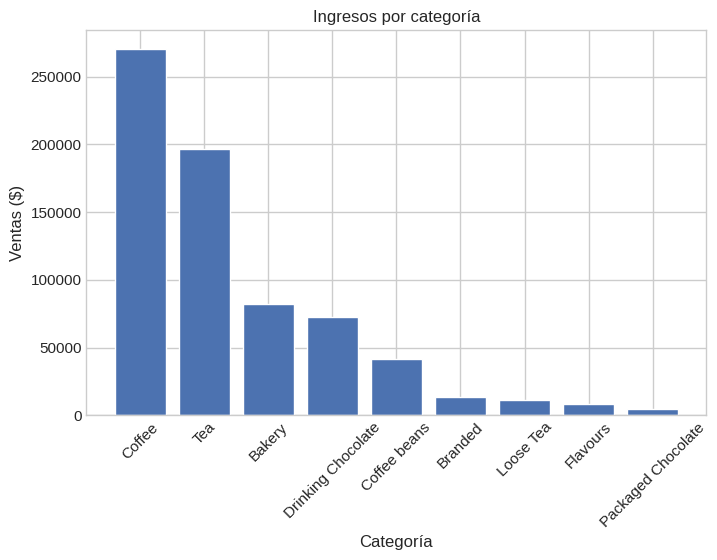

In [116]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    df_category["product_category"],
    df_category["net_sales"]
)

plt.title("Ingresos por categoría")
plt.xlabel("Categoría")
plt.ylabel("Ventas")

plt.xticks(rotation=45)

plt.show()

Productos más vendidos

In [121]:
query = """
SELECT
    product_type,
    units,
    net_sales
FROM analitica.v_kpi_sales_by_product
ORDER BY net_sales DESC
LIMIT 10
"""

df_top_products = pd.read_sql(query, engine)

df_top_products

,product_type,units,net_sales
0,Hot chocolate,4453,21151.75
1,Hot chocolate,4668,21006.00
2,Barista Espresso,4497,19112.25
3,Barista Espresso,4151,17641.75
4,Brewed Chai tea,4346,17384.00
5,Barista Espresso,4602,17257.50
6,Premium brewed coffee,4395,16481.25
7,Hot chocolate,4329,16233.75
8,Barista Espresso,4266,15997.50
9,Organic brewed coffee,4317,15109.50


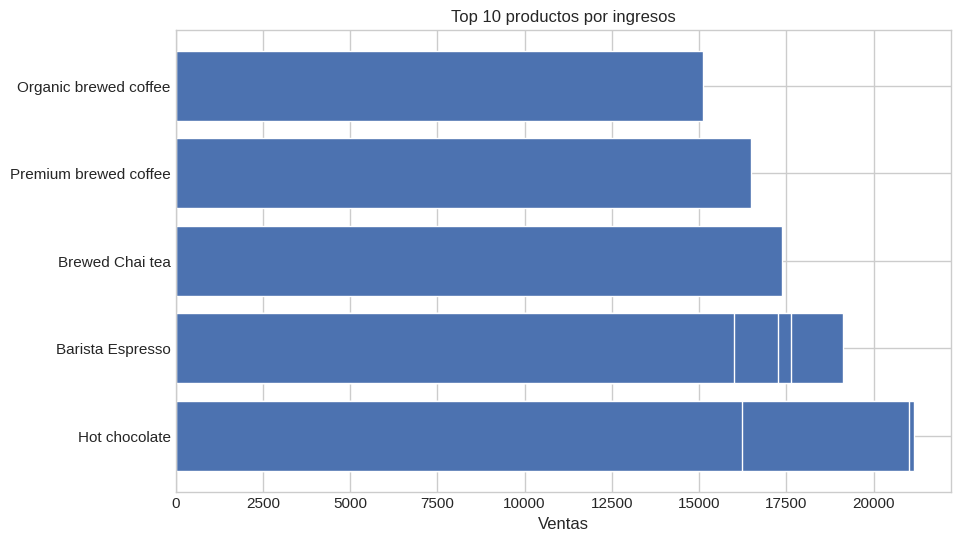

In [119]:
plt.figure(figsize=(10,6))

plt.barh(
    df_top_products["product_type"],
    df_top_products["net_sales"]
)

plt.title("Top 10 productos por ingresos")
plt.xlabel("Ventas")

plt.show()

6.7 Patrones temporales

¿Existen diferencias según el día de la semana?